In [10]:
from groq import Groq
import os

client = Groq(api_key=os.getenv("GROQ_API_KEY"))

try:
    models = client.models.list()
    print("API key works! Found models:", [m.id for m in models.data[:3]])
except Exception as e:
    print("API key problem:", e)

API key works! Found models: ['playai-tts', 'playai-tts-arabic', 'meta-llama/llama-4-scout-17b-16e-instruct']


In [ ]:
"""
LangGraph Quiz Agent - Topic-Based Adaptive Learning
Clean output, proper topic naming, no duplicates
"""

import json
import base64
from typing import TypedDict, Literal, Optional
from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime
import os
import argparse
import sys
import hashlib
import random

from langgraph.graph import StateGraph, END, START
from groq import Groq
from rake_nltk import Rake
import nltk

# ============================================================================
# CONFIGURATION
# ============================================================================

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TOPICS_FILE = Path("topics_knowledge.json")
SESSIONS_DIR = Path("quiz_sessions")
SESSIONS_DIR.mkdir(exist_ok=True)

# Suppress NLTK download messages
import logging
logging.getLogger('nltk').setLevel(logging.ERROR)

try:
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
except:
    pass

# ============================================================================
# DOMAIN MODELS
# ============================================================================

@dataclass
class Topic:
    id: str
    name: str
    keywords: list[str]
    mastery_score: float
    question_count: int
    total_score: int
    last_updated: str
    content_samples: list[str]

@dataclass
class QuestionRecord:
    question_text: str
    user_answer: str
    score: int
    feedback: str

# ============================================================================
# STATE DEFINITION
# ============================================================================

class QuizState(TypedDict):
    user_id: str
    session_id: str
    system_prompt: str
    md_paths: list[str]
    image_paths: list[str]
    extracted_keywords: list[str]
    raw_content: str
    image_descriptions: list[str]
    topic_id: str
    topic_name: str
    current_mastery: float
    question_text: str
    user_answer: Optional[str]
    difficulty_level: str

# ============================================================================
# TOPIC KNOWLEDGE BASE
# ============================================================================

class TopicKnowledgeBase:
    """Manages topic-based learning progress"""
    
    def __init__(self, file_path: Path):
        self.file_path = file_path
        self._initialize()
    
    def _initialize(self):
        if not self.file_path.exists():
            self._write({"topics": {}, "keyword_to_topic": {}})
    
    def _read(self) -> dict:
        try:
            return json.loads(self.file_path.read_text())
        except:
            return {"topics": {}, "keyword_to_topic": {}}
    
    def _write(self, data: dict):
        self.file_path.write_text(json.dumps(data, indent=2))
    
    def _clean_topic_name(self, name: str) -> str:
        """Clean up topic name from markdown artifacts"""
        # Remove markdown symbols and clean up
        cleaned = name.replace('**', '').replace('#', '').replace('*', '')
        cleaned = ' '.join(cleaned.split())  # Normalize whitespace
        
        # Capitalize properly
        words = cleaned.split()
        if len(words) > 0:
            # Take first 3-5 meaningful words
            meaningful_words = [w for w in words if len(w) > 2 and not w.isdigit()][:4]
            if meaningful_words:
                return ' '.join(word.capitalize() for word in meaningful_words)
        
        return "General Topic"
    
    def identify_topic(self, keywords: list[str], content_sample: str) -> tuple[str, str, float]:
        """Identify topic from keywords or create new one"""
        data = self._read()
        
        # Clean keywords
        clean_keywords = []
        for kw in keywords[:10]:
            cleaned = kw.replace('**', '').replace('#', '').strip()
            if len(cleaned) > 3 and not cleaned.isdigit():
                clean_keywords.append(cleaned)
        
        if not clean_keywords:
            clean_keywords = ["general", "topic"]
        
        keyword_set = set(kw.lower() for kw in clean_keywords[:5])
        
        # Try to match existing topic
        best_match_id = None
        best_match_score = 0
        
        for topic_id, topic_data in data["topics"].items():
            topic_keywords = set(kw.lower() for kw in topic_data["keywords"])
            overlap = len(keyword_set & topic_keywords)
            
            if overlap >= 2:
                match_score = overlap / len(keyword_set | topic_keywords)
                if match_score > best_match_score:
                    best_match_score = match_score
                    best_match_id = topic_id
        
        if best_match_id and best_match_score > 0.3:
            topic_data = data["topics"][best_match_id]
            return (best_match_id, topic_data["name"], topic_data["mastery_score"])
        else:
            # Create new topic with clean name
            topic_name = self._generate_topic_name(clean_keywords, content_sample)
            topic_id = f"topic_{hashlib.md5(topic_name.encode()).hexdigest()[:12]}"
            
            new_topic = Topic(
                id=topic_id,
                name=topic_name,
                keywords=clean_keywords[:5],
                mastery_score=0.0,
                question_count=0,
                total_score=0,
                last_updated=datetime.now().isoformat(),
                content_samples=[content_sample[:200]]
            )
            
            data["topics"][topic_id] = asdict(new_topic)
            
            for kw in clean_keywords[:5]:
                data["keyword_to_topic"][kw.lower()] = topic_id
            
            self._write(data)
            
            return (topic_id, topic_name, 0.0)
    
    def _generate_topic_name(self, keywords: list[str], content: str) -> str:
        """Generate meaningful topic name"""
        
        # Filter meaningful keywords
        meaningful = [kw for kw in keywords if len(kw) > 3 and not any(char.isdigit() for char in kw)]
        
        if not meaningful:
            meaningful = keywords
        
        # Take top 2-3 keywords
        top = meaningful[:3]
        
        if len(top) == 1:
            return self._clean_topic_name(top[0])
        elif len(top) == 2:
            return self._clean_topic_name(f"{top[0]} and {top[1]}")
        else:
            return self._clean_topic_name(f"{top[0]}, {top[1]}, {top[2]}")
    
    def update_topic_score(self, topic_id: str, new_score: int, question_text: str, answer: str, feedback: str):
        """Update topic mastery"""
        data = self._read()
        
        if topic_id not in data["topics"]:
            return
        
        topic = data["topics"][topic_id]
        
        topic["question_count"] += 1
        topic["total_score"] += new_score
        topic["mastery_score"] = topic["total_score"] / topic["question_count"]
        topic["last_updated"] = datetime.now().isoformat()
        
        if "questions" not in topic:
            topic["questions"] = []
        
        topic["questions"].append({
            "question": question_text,
            "answer": answer,
            "score": new_score,
            "feedback": feedback,
            "timestamp": datetime.now().isoformat()
        })
        
        data["topics"][topic_id] = topic
        self._write(data)
    
    def get_topic(self, topic_id: str) -> dict:
        data = self._read()
        return data["topics"].get(topic_id, {})
    
    def get_all_topics(self) -> list[dict]:
        data = self._read()
        return list(data["topics"].values())

# ============================================================================
# SESSION STORAGE
# ============================================================================

class SessionStorage:
    """Store session data"""
    
    def __init__(self, sessions_dir: Path):
        self.sessions_dir = sessions_dir
    
    def save_session(self, session_id: str, session_data: dict):
        session_file = self.sessions_dir / f"{session_id}.json"
        session_file.write_text(json.dumps(session_data, indent=2))

# ============================================================================
# FILE DISCOVERY
# ============================================================================

def discover_files(path_str: str) -> tuple[list[str], list[str]]:
    path_str = path_str.strip().strip('"').strip("'")
    path = Path(path_str)
    
    md_files = []
    image_files = []
    image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.svg', '.webp'}
    
    if not path.exists():
        return [], []
    
    if path.is_file():
        if path.suffix.lower() in ['.md', '.markdown']:
            md_files.append(str(path.absolute()))
        elif path.suffix.lower() in image_extensions:
            image_files.append(str(path.absolute()))
        return md_files, image_files
    
    if path.is_dir():
        for pattern in ['*.md', '*.markdown']:
            md_files.extend(path.rglob(pattern))
        
        for ext in image_extensions:
            image_files.extend(path.rglob(f'*{ext}'))
            image_files.extend(path.rglob(f'*{ext.upper()}'))
        
        return [str(f.absolute()) for f in md_files], [str(f.absolute()) for f in image_files]
    
    return [], []

def validate_input_files(file_paths: list[str]) -> tuple[list[str], list[str]]:
    all_md_files = []
    all_image_files = []
    
    for path_str in file_paths:
        md_files, img_files = discover_files(path_str)
        
        if md_files or img_files:
            all_md_files.extend(md_files)
            all_image_files.extend(img_files)
    
    return all_md_files, all_image_files

# ============================================================================
# KEYWORD EXTRACTOR
# ============================================================================

class KeywordExtractor:
    
    def __init__(self):
        self.rake = Rake()
    
    def extract(self, text: str, top_n: int = 10) -> list[str]:
        self.rake.extract_keywords_from_text(text)
        ranked_phrases = self.rake.get_ranked_phrases()
        return ranked_phrases[:top_n]

# ============================================================================
# IMAGE DESCRIPTOR
# ============================================================================

class ImageDescriptor:
    
    def __init__(self, api_key: str):
        self.client = Groq(api_key=api_key)
        self.model = "meta-llama/llama-4-scout-17b-16e-instruct"
    
    def describe_image(self, image_path: str) -> str:
        try:
            if not Path(image_path).exists():
                return ""
            
            with open(image_path, "rb") as f:
                image_data = base64.standard_b64encode(f.read()).decode("utf-8")
            
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[{
                    "role": "user",
                    "content": [
                        {"type": "text", "text": "Describe this educational image focusing on key concepts."},
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_data}"}}
                    ]
                }],
                temperature=0.3,
                max_tokens=1024
            )
            
            return response.choices[0].message.content
        except:
            return ""

# ============================================================================
# QUESTION GENERATOR
# ============================================================================

class AdaptiveQuestionGenerator:
    
    def __init__(self, api_key: str):
        self.client = Groq(api_key=api_key)
        self.model = "llama-3.3-70b-versatile"
    
    def generate(self, content: str, topic_name: str, mastery_score: float, system_prompt: str) -> str:
        
        if mastery_score < 2.0:
            difficulty_instruction = "Ask a BASIC question about fundamental concepts."
        elif mastery_score < 3.5:
            difficulty_instruction = "Ask an INTERMEDIATE question requiring understanding of connections."
        else:
            difficulty_instruction = "Ask an ADVANCED question requiring deep analysis."
        
        user_prompt = f"""Generate ONE question about: "{topic_name}"

Content:
{content[:1500]}

{difficulty_instruction}

Return ONLY the question, no preamble.

Question:"""

        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.75,
                max_tokens=200
            )
            
            question = response.choices[0].message.content.strip()
            
            for prefix in ["Based on", "Here's", "Question:", "Based on the"]:
                if question.lower().startswith(prefix.lower()):
                    parts = question.split(":", 1)
                    if len(parts) > 1:
                        question = parts[1].strip()
            
            return question.strip('"').strip("'").strip()
        
        except Exception as e:
            return f"What are the key concepts in {topic_name}?"

# ============================================================================
# ANSWER SCORER
# ============================================================================

class AnswerScorer:
    
    def __init__(self, api_key: str):
        self.client = Groq(api_key=api_key)
        self.model = "llama-3.3-70b-versatile"
    
    def score(self, question: str, answer: str, reference: str, system_prompt: str) -> tuple[int, str]:
        
        prompt = f"""Score this answer (1-5).

Question: {question}
Reference: {reference[:800]}
Answer: {answer}

Format:
SCORE: [1-5]
FEEDBACK: [brief feedback]"""

        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.3,
                max_tokens=300
            )
            
            result = response.choices[0].message.content.strip()
            
            score = 3
            feedback = ""
            
            for line in result.split('\n'):
                if line.startswith('SCORE:'):
                    try:
                        score = int(line.split(':')[1].strip())
                    except:
                        pass
                elif line.startswith('FEEDBACK:'):
                    feedback = line.split(':', 1)[1].strip()
            
            if not feedback:
                feedback = result
            
            return (score, feedback)
        
        except:
            return (3, "Unable to score answer")

# ============================================================================
# LANGGRAPH NODES
# ============================================================================

topic_kb = TopicKnowledgeBase(TOPICS_FILE)
session_storage = SessionStorage(SESSIONS_DIR)
keyword_extractor = KeywordExtractor()
image_descriptor = ImageDescriptor(GROQ_API_KEY)
question_generator = AdaptiveQuestionGenerator(GROQ_API_KEY)
answer_scorer = AnswerScorer(GROQ_API_KEY)

def initialize_session(state: QuizState) -> dict:
    session_id = f"session_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    default_prompt = """Expert educational AI. Generate clear questions and constructive feedback."""
    
    return {
        "session_id": session_id,
        "system_prompt": state.get("system_prompt", default_prompt)
    }

def extract_content(state: QuizState) -> dict:
    
    md_paths = state.get("md_paths", [])
    img_paths = state.get("image_paths", [])
    
    all_content = []
    for md_path in md_paths:
        content = Path(md_path).read_text(encoding='utf-8')
        all_content.append(content)
    
    combined_content = "\n\n".join(all_content)
    
    keywords = keyword_extractor.extract(combined_content, top_n=15) if combined_content else []
    
    image_descriptions = []
    for img_path in img_paths:
        desc = image_descriptor.describe_image(img_path)
        if desc:
            image_descriptions.append(desc)
            combined_content += f"\n\nImage: {desc}"
    
    return {
        "extracted_keywords": keywords,
        "raw_content": combined_content if combined_content else "Visual content",
        "image_descriptions": image_descriptions
    }

def identify_topic(state: QuizState) -> dict:
    
    keywords = state["extracted_keywords"]
    content = state["raw_content"]
    
    topic_id, topic_name, mastery = topic_kb.identify_topic(keywords, content)
    
    if mastery < 2.0:
        difficulty = "Basic"
    elif mastery < 3.5:
        difficulty = "Intermediate"
    else:
        difficulty = "Advanced"
    
    print(f"\n📚 Topic: {topic_name}")
    print(f"⭐ Mastery: {mastery:.1f}/5.0 | Level: {difficulty}")
    
    return {
        "topic_id": topic_id,
        "topic_name": topic_name,
        "current_mastery": mastery,
        "difficulty_level": difficulty
    }

def generate_question(state: QuizState) -> dict:
    
    question_text = question_generator.generate(
        state["raw_content"],
        state["topic_name"],
        state["current_mastery"],
        state["system_prompt"]
    )
    
    return {"question_text": question_text}

def collect_answer(state: QuizState) -> dict:
    
    print(f"\n{'='*60}")
    print(f"❓ {state['question_text']}")
    print(f"{'='*60}")
    
    if state.get("user_answer"):
        answer = state["user_answer"]
        print(f"💬 {answer}")
    else:
        answer = input("\n💬 Your answer: ").strip()
    
    return {"user_answer": answer}

def score_and_update(state: QuizState) -> dict:
    
    score, feedback = answer_scorer.score(
        state["question_text"],
        state["user_answer"],
        state["raw_content"],
        state["system_prompt"]
    )
    
    topic_kb.update_topic_score(
        state["topic_id"],
        score,
        state["question_text"],
        state["user_answer"],
        feedback
    )
    
    session_data = {
        "session_id": state["session_id"],
        "topic_id": state["topic_id"],
        "topic_name": state["topic_name"],
        "question": state["question_text"],
        "answer": state["user_answer"],
        "score": score,
        "feedback": feedback,
        "mastery_before": state["current_mastery"],
        "difficulty": state["difficulty_level"],
        "timestamp": datetime.now().isoformat()
    }
    
    session_storage.save_session(state["session_id"], session_data)
    
    # Get updated mastery
    topic_data = topic_kb.get_topic(state["topic_id"])
    new_mastery = topic_data.get("mastery_score", 0.0)
    
    print(f"\n✅ Score: {score}/5")
    print(f"💡 {feedback}")
    print(f"📈 New Mastery: {new_mastery:.1f}/5.0")
    
    return {}

# ============================================================================
# GRAPH
# ============================================================================

def build_graph() -> StateGraph:
    
    graph = StateGraph(QuizState)
    
    graph.add_node("initialize_session", initialize_session)
    graph.add_node("extract_content", extract_content)
    graph.add_node("identify_topic", identify_topic)
    graph.add_node("generate_question", generate_question)
    graph.add_node("collect_answer", collect_answer)
    graph.add_node("score_and_update", score_and_update)
    
    graph.add_edge(START, "initialize_session")
    graph.add_edge("initialize_session", "extract_content")
    graph.add_edge("extract_content", "identify_topic")
    graph.add_edge("identify_topic", "generate_question")
    graph.add_edge("generate_question", "collect_answer")
    graph.add_edge("collect_answer", "score_and_update")
    graph.add_edge("score_and_update", END)
    
    return graph.compile()

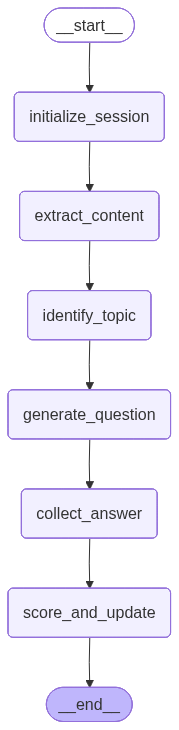

In [3]:
from IPython.display import Image, display

# Create workflow
workflow = build_graph()

# Get graph object
graph = workflow.get_graph(xray=True)  # xray=True gives you full detail

# Render as PNG Mermaid diagram
png_data = graph.draw_mermaid_png()

# Show in notebook
display(Image(png_data))


In [ ]:

# ============================================================================
# MAIN
# ============================================================================

def main():
    parser = argparse.ArgumentParser(description="Adaptive Quiz")
    parser.add_argument("--files", nargs="+")
    parser.add_argument("--user-id", default="user_001")
    parser.add_argument("--answer")
    parser.add_argument("--topics", action="store_true", help="Show all topics")
    
    args = parser.parse_args()
    
    if args.topics:
        print("\n📚 TOPIC MASTERY")
        print("=" * 60)
        topics = topic_kb.get_all_topics()
        if not topics:
            print("No topics yet. Start learning!")
        else:
            for topic in sorted(topics, key=lambda x: x['mastery_score'], reverse=True):
                print(f"\n{topic['name']}")
                print(f"  ⭐ Mastery: {topic['mastery_score']:.1f}/5.0")
                print(f"  📝 Questions: {topic['question_count']}")
        return
    
    print("=" * 60)
    print("🎓 ADAPTIVE QUIZ AGENT")
    print("=" * 60)
    
    if args.files:
        md_paths, img_paths = validate_input_files(args.files)
    else:
        print("\n📁 Enter file/directory path:")
        user_input = input(">>> ").strip()
        if not user_input:
            sys.exit(1)
        md_paths, img_paths = validate_input_files([user_input])
    
    if not md_paths and not img_paths:
        print("❌ No files found")
        sys.exit(1)
    
    print(f"✓ Loaded {len(md_paths)} markdown, {len(img_paths)} images")
    
    app = build_graph()
    
    initial_state = {
        "user_id": args.user_id,
        "session_id": "",
        "system_prompt": "",
        "md_paths": md_paths,
        "image_paths": img_paths,
        "extracted_keywords": [],
        "raw_content": "",
        "image_descriptions": [],
        "topic_id": "",
        "topic_name": "",
        "current_mastery": 0.0,
        "question_text": "",
        "user_answer": args.answer,
        "difficulty_level": ""
    }
    
    result = app.invoke(initial_state)
    
    print(f"\n💾 Session: {result['session_id']}")

if __name__ == "__main__":
    main()
